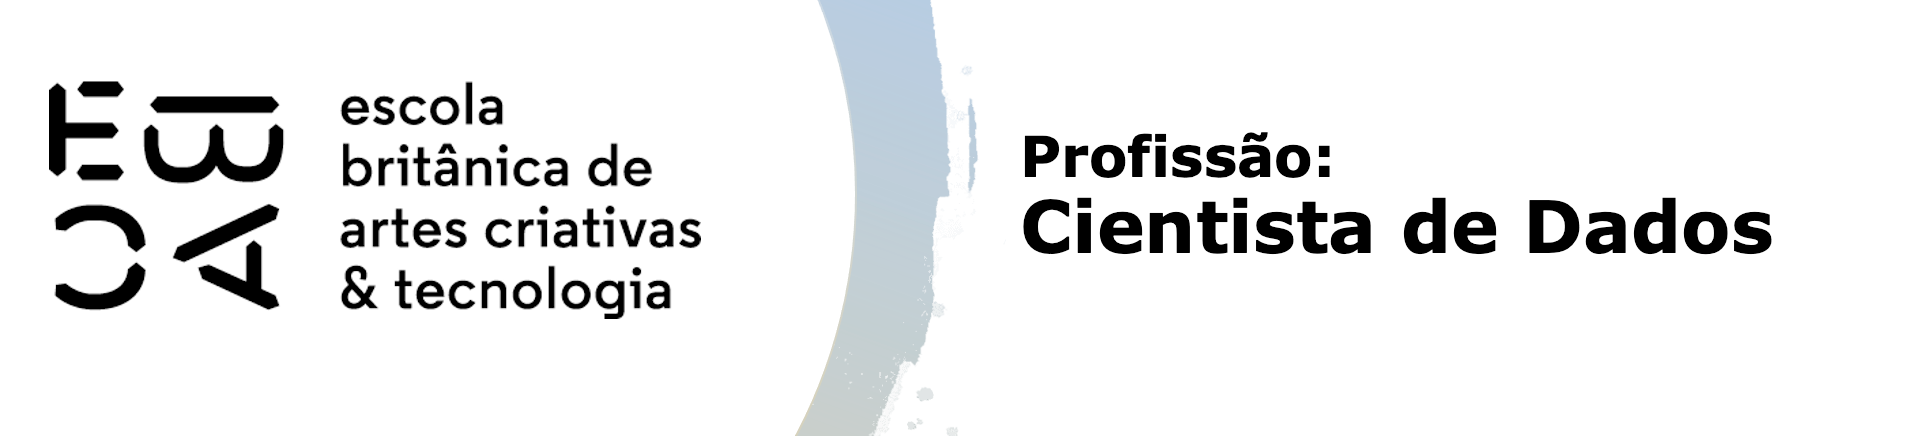

# Tarefa I

Neste projeto, estamos construindo um credit scoring para cartão de crédito, em um desenho amostral com 15 safras, e utilizando 12 meses de performance.

Carregue a base de dados ```credit_scoring.ftr```.

In [3]:
import pandas as pd

df = pd.read_feather('credit_scoring.ftr')
df.head()

,data_ref,index,sexo,posse_de_veiculo,posse_de_imovel,qtd_filhos,tipo_renda,educacao,estado_civil,tipo_residencia,idade,tempo_emprego,qt_pessoas_residencia,renda,mau
0,2015-01-01,5733,F,N,N,0,Empresário,Médio,Solteiro,Casa,43,6.873973,1.0,2515.39,False
1,2015-01-01,727,F,S,S,0,Assalariado,Médio,Casado,Casa,35,4.526027,2.0,3180.19,False
2,2015-01-01,6374,F,N,N,2,Assalariado,Médio,Casado,Casa,31,0.243836,4.0,1582.29,False
3,2015-01-01,9566,F,N,N,0,Assalariado,Médio,Casado,Casa,54,12.772603,2.0,13721.17,False
4,2015-01-01,9502,F,S,N,0,Assalariado,Superior incompleto,Solteiro,Casa,31,8.432877,1.0,2891.08,False


## Amostragem

Separe os três últimos meses como safras de validação *out of time* (oot).

Variáveis:<br>
Considere que a variável ```data_ref``` não é uma variável explicativa, é somente uma variável indicadora da safra, e não deve ser utilizada na modelagem. A variávei ```index``` é um identificador do cliente, e também não deve ser utilizada como covariável (variável explicativa). As restantes podem ser utilizadas para prever a inadimplência, incluindo a renda.


In [4]:

# Variáveis preditoras (excluindo identificadores e target)
vars_quali = ['sexo', 'posse_de_veiculo', 'posse_de_imovel', 'tipo_renda',
              'educacao', 'estado_civil', 'tipo_residencia']
vars_quant = ['qtd_filhos', 'idade', 'tempo_emprego', 'qt_pessoas_residencia', 'renda']
features   = vars_quant + vars_quali
target     = 'mau'

# Ordenar safras disponíveis
datas = sorted(df['data_ref'].unique())
print(f'Total de safras: {len(datas)}')
for d in datas:
    print(f'  {str(d)[:10]}')

# Separar últimas 3 safras como OOT
datas_oot = datas[-3:]
datas_dev = datas[:-3]

df_oot = df[df['data_ref'].isin(datas_oot)].copy()
df_dev = df[df['data_ref'].isin(datas_dev)].copy()

X_dev = df_dev[features]
y_dev = df_dev[target]
X_oot = df_oot[features]
y_oot = df_oot[target]

print(f'\nDesenvolvimento : {df_dev.shape[0]:>6} linhas  |  {len(datas_dev)} safras')
print(f'Out of Time     : {df_oot.shape[0]:>6} linhas  |  {len(datas_oot)} safras')
print(f'Taxa mau (dev)  : {y_dev.mean():.2%}')
print(f'Taxa mau (oot)  : {y_oot.mean():.2%}')


Total de safras: 15
  2015-01-01
  2015-02-01
  2015-03-01
  2015-04-01
  2015-05-01
  2015-06-01
  2015-07-01
  2015-08-01
  2015-09-01
  2015-10-01
  2015-11-01
  2015-12-01
  2016-01-01
  2016-02-01
  2016-03-01

Desenvolvimento : 600000 linhas  |  12 safras
Out of Time     : 150000 linhas  |  3 safras
Taxa mau (dev)  : 6.11%
Taxa mau (oot)  : 14.67%


## Descritiva básica univariada

- Descreva a base quanto ao número de linhas, número de linhas para cada mês em ```data_ref```.
- Faça uma descritiva básica univariada de cada variável. Considere as naturezas diferentes: qualitativas e quantitativas.

Total de linhas : 750000
Total de colunas: 15

Linhas por safra (data_ref):
  data_ref     n
2015-01-01 50000
2015-02-01 50000
2015-03-01 50000
2015-04-01 50000
2015-05-01 50000
2015-06-01 50000
2015-07-01 50000
2015-08-01 50000
2015-09-01 50000
2015-10-01 50000
2015-11-01 50000
2015-12-01 50000
2016-01-01 50000
2016-02-01 50000
2016-03-01 50000

--- Missings ---
tempo_emprego    125957
dtype: int64

=== Variáveis Qualitativas ===

sexo:
           n      %
sexo               
F     504580  67.28
M     245420  32.72

posse_de_veiculo:
                       n      %
posse_de_veiculo               
N                 457954  61.06
S                 292046  38.94

posse_de_imovel:
                      n      %
posse_de_imovel               
S                503692  67.16
N                246308  32.84

tipo_renda:
                       n      %
tipo_renda                     
Assalariado       385740  51.43
Empresário        172712  23.03
Pensionista       126265  16.84
Servidor público

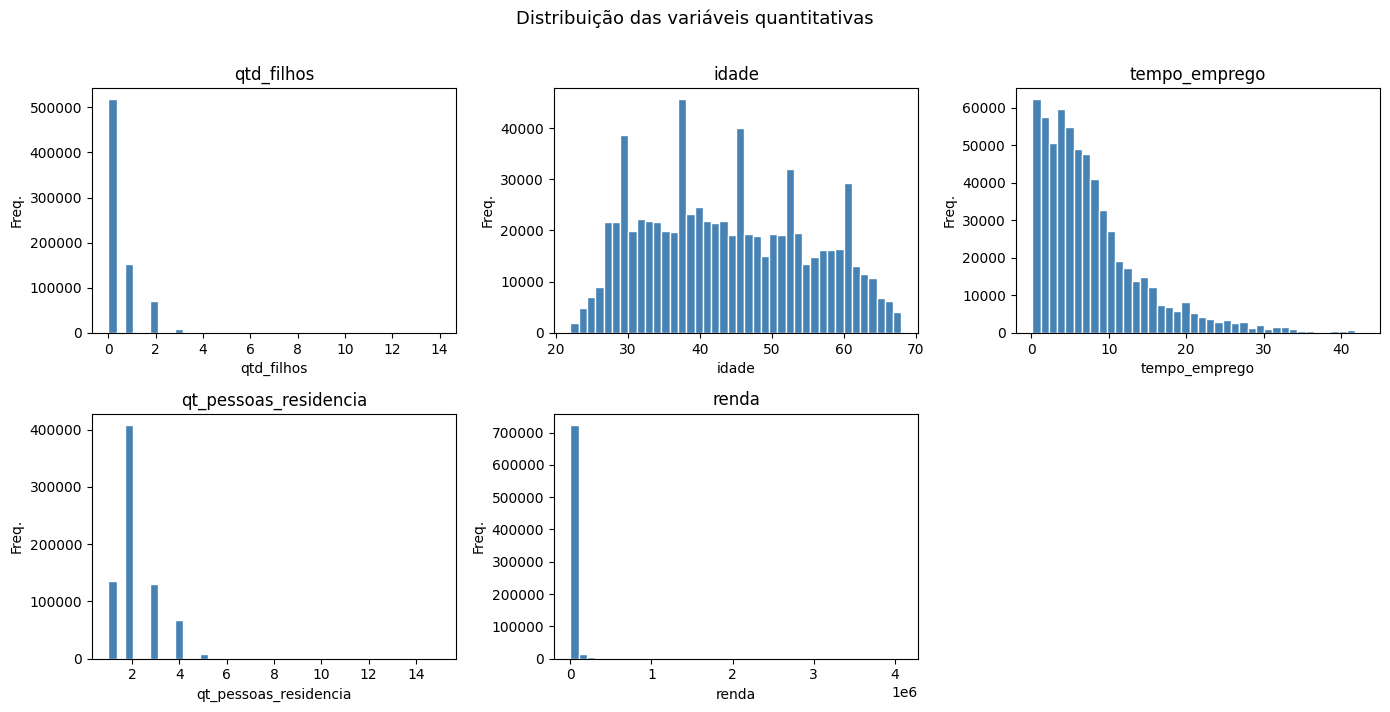

In [5]:

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# ── Dimensões gerais ──────────────────────────────────────────────────────────
print(f'Total de linhas : {df.shape[0]}')
print(f'Total de colunas: {df.shape[1]}')
print(f'\nLinhas por safra (data_ref):')
print(df.groupby('data_ref').size().rename('n').reset_index().to_string(index=False))

# ── Missings ─────────────────────────────────────────────────────────────────
miss = df[features].isnull().sum()
miss = miss[miss > 0]
print('\n--- Missings ---')
print(miss if len(miss) else 'Nenhum missing encontrado nas variáveis preditoras.')

# ── Variáveis qualitativas ────────────────────────────────────────────────────
print('\n=== Variáveis Qualitativas ===')
for col in vars_quali:
    tab = df[col].value_counts(dropna=False).rename('n')
    tab = tab.to_frame()
    tab['%'] = (tab['n'] / tab['n'].sum() * 100).round(2)
    print(f'\n{col}:\n{tab}')

# ── Variáveis quantitativas ───────────────────────────────────────────────────
print('\n=== Variáveis Quantitativas ===')
print(df[vars_quant].describe().T.round(2))

# ── Histogramas das quantitativas ────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()
for i, col in enumerate(vars_quant):
    axes[i].hist(df[col].dropna(), bins=40, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Freq.')
axes[-1].axis('off')
plt.suptitle('Distribuição das variáveis quantitativas', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


## Descritiva bivariada

Faça uma análise descritiva bivariada de cada variável

=== Taxa de inadimplência por variável qualitativa ===

sexo:
           n taxa_mau_%
sexo                   
F     504580      8.05%
M     245420      7.34%

posse_de_veiculo:
                       n taxa_mau_%
posse_de_veiculo                   
N                 457954      7.88%
S                 292046      7.73%

posse_de_imovel:
                      n taxa_mau_%
posse_de_imovel                   
N                246308      8.85%
S                503692      7.32%

tipo_renda:
                       n taxa_mau_%
tipo_renda                         
Pensionista       126265      8.27%
Assalariado       385740      8.09%
Empresário        172712      7.65%
Servidor público   64922      5.81%
Bolsista             361      4.16%

educacao:
                          n taxa_mau_%
educacao                              
Fundamental            8575      9.17%
Superior incompleto   29471      8.30%
Médio                506836      8.04%
Pós graduação           812      7.27%
Superior co

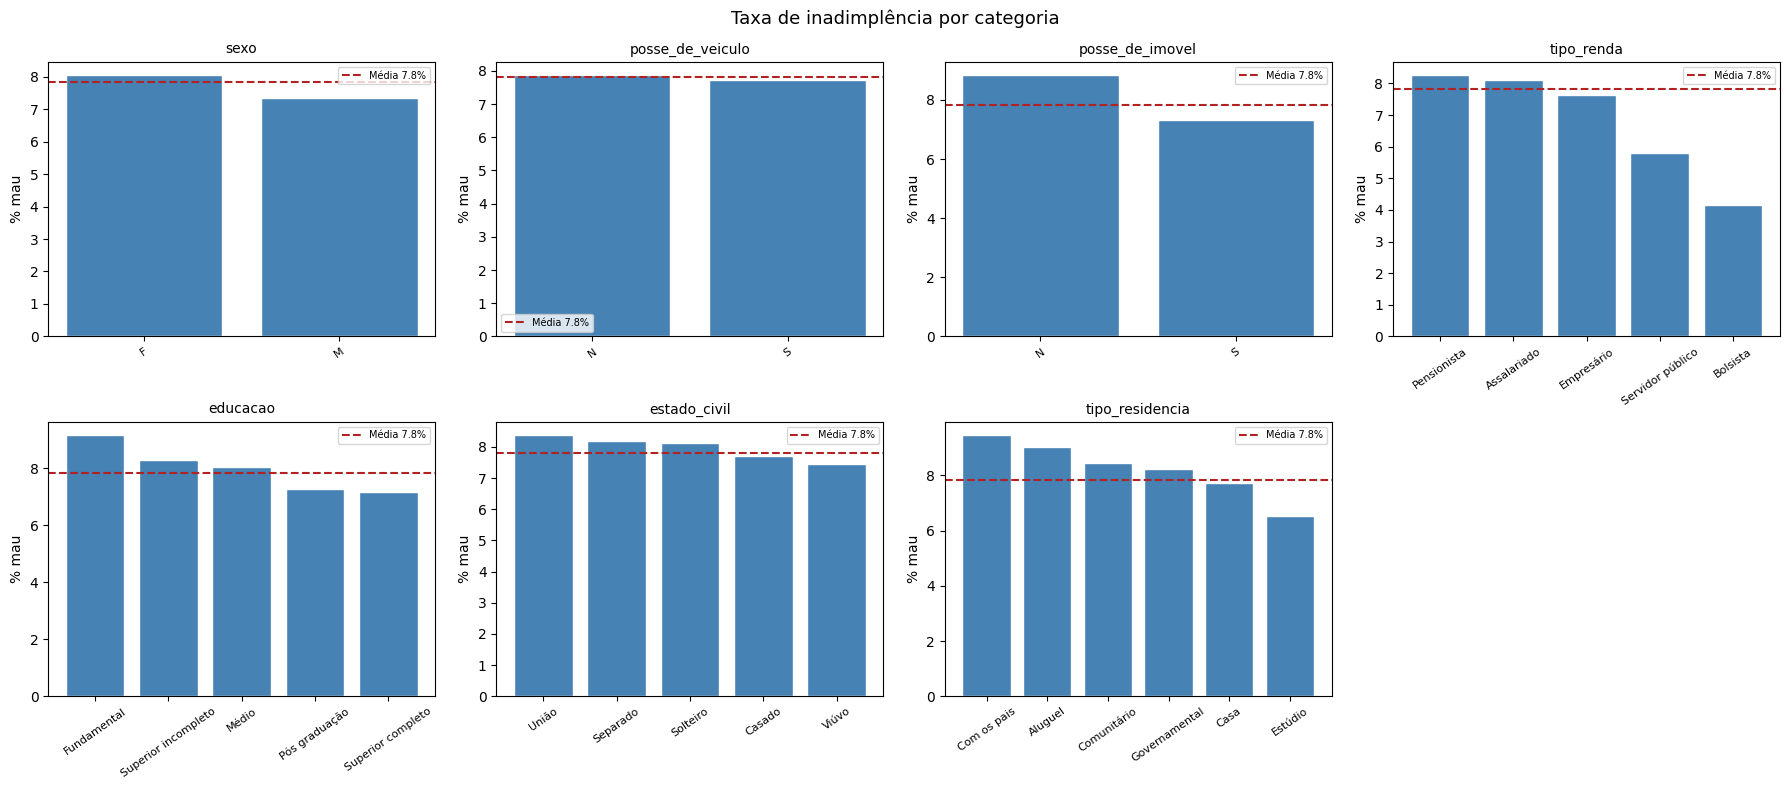


=== Estatísticas das variáveis quantitativas por inadimplência ===

qtd_filhos:
          count  mean   std  min  25%  50%  75%   max
mau                                                  
False  691357.0  0.43  0.74  0.0  0.0  0.0  1.0  14.0
True    58643.0  0.45  0.76  0.0  0.0  0.0  1.0  14.0 

idade:
          count   mean    std   min   25%   50%   75%   max
mau                                                        
False  691357.0  43.90  11.19  22.0  35.0  43.0  53.0  68.0
True    58643.0  42.73  11.59  22.0  33.0  41.0  52.0  68.0 

tempo_emprego:
          count  mean   std   min   25%   50%    75%    max
mau                                                        
False  575806.0   8.0  6.81  0.12  3.22  6.35  10.56  42.91
True    48237.0   4.7  3.91  0.12  1.72  3.85   6.62  42.91 

qt_pessoas_residencia:
          count  mean   std  min  25%  50%  75%   max
mau                                                  
False  691357.0  2.21  0.90  1.0  2.0  2.0  3.0  15.0
True    58

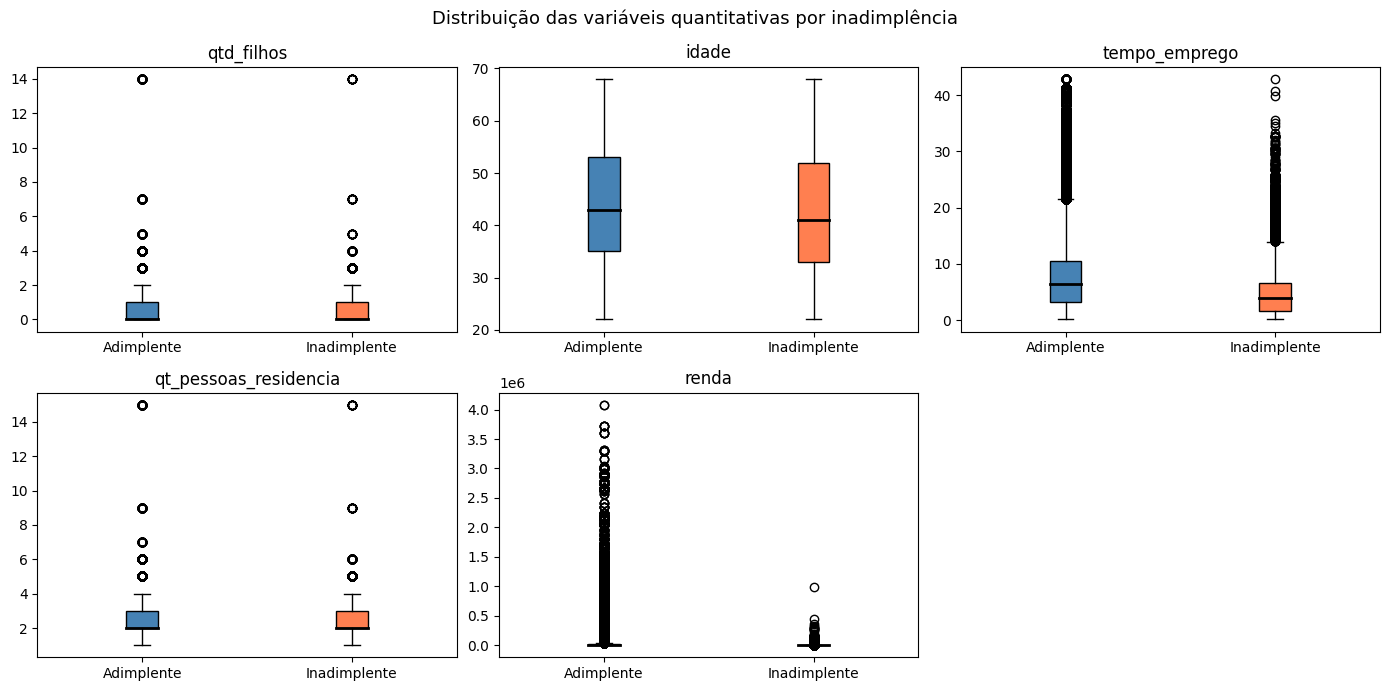

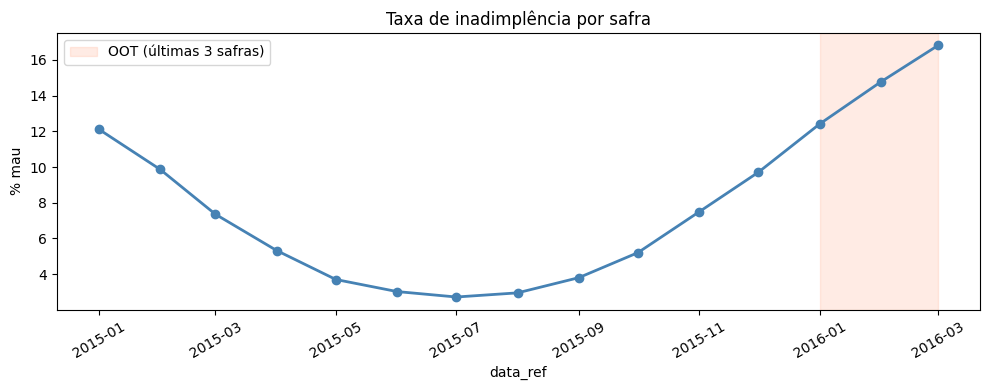

In [6]:

import matplotlib.pyplot as plt
import numpy as np

# ══════════════════════════════════════════════════════════════════════════════
# 1. QUALITATIVAS × MAU
# ══════════════════════════════════════════════════════════════════════════════
print('=== Taxa de inadimplência por variável qualitativa ===\n')
for col in vars_quali:
    tab = (df.groupby(col)[target]
             .agg(['mean', 'count'])
             .rename(columns={'mean': 'taxa_mau', 'count': 'n'})
             .sort_values('taxa_mau', ascending=False))
    tab['taxa_mau_%'] = tab['taxa_mau'].map('{:.2%}'.format)
    print(f'{col}:\n{tab[["n", "taxa_mau_%"]]}\n')

# Gráfico de barras — taxa de mau por categoria
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
media_geral = df[target].mean() * 100
for i, col in enumerate(vars_quali):
    tab = df.groupby(col)[target].mean().sort_values(ascending=False) * 100
    axes[i].bar(tab.index, tab.values, color='steelblue', edgecolor='white')
    axes[i].axhline(media_geral, color='firebrick', linestyle='--',
                    lw=1.5, label=f'Média {media_geral:.1f}%')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel('% mau')
    axes[i].tick_params(axis='x', rotation=35, labelsize=8)
    axes[i].legend(fontsize=7)
axes[-1].axis('off')
plt.suptitle('Taxa de inadimplência por categoria', fontsize=13)
plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# 2. QUANTITATIVAS × MAU
# ══════════════════════════════════════════════════════════════════════════════
print('\n=== Estatísticas das variáveis quantitativas por inadimplência ===\n')
for col in vars_quant:
    print(f'{col}:')
    print(df.groupby(target)[col].describe().round(2), '\n')

# Boxplots — distribuição de cada variável quantitativa por mau
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()
for i, col in enumerate(vars_quant):
    bom  = df.loc[df[target] == False, col].dropna()
    mau  = df.loc[df[target] == True,  col].dropna()
    bp = axes[i].boxplot(
        [bom, mau],
        labels=['Adimplente', 'Inadimplente'],
        patch_artist=True,
        medianprops=dict(color='black', lw=2),
    )
    bp['boxes'][0].set_facecolor('steelblue')
    bp['boxes'][1].set_facecolor('coral')
    axes[i].set_title(col)
axes[-1].axis('off')
plt.suptitle('Distribuição das variáveis quantitativas por inadimplência', fontsize=13)
plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# 3. VARIÁVEL ALVO × TEMPO (taxa de mau por safra)
# ══════════════════════════════════════════════════════════════════════════════
taxa_safra = df.groupby('data_ref')[target].mean() * 100
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(taxa_safra.index, taxa_safra.values, marker='o', color='steelblue', lw=2)
ax.axvspan(taxa_safra.index[-3], taxa_safra.index[-1],
           alpha=0.15, color='coral', label='OOT (últimas 3 safras)')
ax.set_title('Taxa de inadimplência por safra')
ax.set_ylabel('% mau')
ax.set_xlabel('data_ref')
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## Desenvolvimento do modelo

Desenvolva um modelo de *credit scoring* através de uma regressão logística.

- Trate valores missings e outliers
- Trate 'zeros estruturais'
- Faça agrupamentos de categorias conforme vimos em aula
- Proponha uma equação preditiva para 'mau'
- Caso hajam categorias não significantes, justifique

In [7]:

import numpy as np
import pandas as pd
from sklearn.linear_model    import LogisticRegression
from sklearn.preprocessing   import StandardScaler
from sklearn.impute          import SimpleImputer

# ── Cópias de trabalho ────────────────────────────────────────────────────────
X_dev_m = X_dev.copy()
X_oot_m = X_oot.copy()

# ── Tratamento de missings (vetorizado) ───────────────────────────────────────
medianas = X_dev_m[vars_quant].median()
X_dev_m[vars_quant] = X_dev_m[vars_quant].fillna(medianas)
X_oot_m[vars_quant] = X_oot_m[vars_quant].fillna(medianas)

modas = X_dev_m[vars_quali].mode().iloc[0]
X_dev_m[vars_quali] = X_dev_m[vars_quali].fillna(modas)
X_oot_m[vars_quali] = X_oot_m[vars_quali].fillna(modas)

print('Missings após tratamento (dev):', X_dev_m.isnull().sum().sum())

# ── Tratamento de outliers – winsorização (p1 / p99, vetorizado) ──────────────
p01 = X_dev_m[vars_quant].quantile(0.01)
p99 = X_dev_m[vars_quant].quantile(0.99)
X_dev_m[vars_quant] = X_dev_m[vars_quant].clip(lower=p01, upper=p99, axis=1)
X_oot_m[vars_quant] = X_oot_m[vars_quant].clip(lower=p01, upper=p99, axis=1)

# ── Agrupamento de categorias ─────────────────────────────────────────────────
map_renda = {'Empresário': 'Empresário', 'Assalariado': 'Assalariado',
             'Servidor público': 'Servidor público',
             'Pensionista': 'Outro', 'Bolsista': 'Outro'}
map_educ  = {'Médio': 'Médio', 'Superior incompleto': 'Superior incompleto',
             'Superior completo': 'Superior+', 'Pós graduação': 'Superior+',
             'Fundamental': 'Fundamental', 'Primário': 'Fundamental'}

for X in [X_dev_m, X_oot_m]:
    X['tipo_renda'] = X['tipo_renda'].map(map_renda).fillna('Outro')
    X['educacao']   = X['educacao'].map(map_educ).fillna('Fundamental')

# ── Dummies ───────────────────────────────────────────────────────────────────
X_dev_d = pd.get_dummies(X_dev_m, columns=vars_quali, drop_first=True)
X_oot_d = pd.get_dummies(X_oot_m, columns=vars_quali, drop_first=True)
X_oot_d = X_oot_d.reindex(columns=X_dev_d.columns, fill_value=0)

# ── Padronização ──────────────────────────────────────────────────────────────
scaler = StandardScaler()
X_dev_sc = scaler.fit_transform(X_dev_d)
X_oot_sc = scaler.transform(X_oot_d)

# ── Modelo (saga → muito mais rápido para n grande) ───────────────────────────
lr = LogisticRegression(max_iter=500, random_state=42, solver='saga', n_jobs=-1)
lr.fit(X_dev_sc, y_dev)

# ── Equação / coeficientes ────────────────────────────────────────────────────
coef_df = (pd.DataFrame({'variavel': X_dev_d.columns, 'coeficiente': lr.coef_[0]})
             .sort_values('coeficiente', ascending=False))
print('\nCoeficientes do modelo (logit):')
print(coef_df.to_string(index=False))


Missings após tratamento (dev): 0

Coeficientes do modelo (logit):
                     variavel  coeficiente
                   qtd_filhos     0.053761
           posse_de_veiculo_S     0.015595
           estado_civil_União     0.012620
                        idade     0.000983
      tipo_residencia_Estúdio    -0.002970
        estado_civil_Separado    -0.008051
  tipo_renda_Servidor público    -0.009020
  tipo_residencia_Comunitário    -0.009272
               educacao_Médio    -0.014320
tipo_residencia_Governamental    -0.015115
  tipo_residencia_Com os pais    -0.015499
 educacao_Superior incompleto    -0.015628
           estado_civil_Viúvo    -0.021623
        estado_civil_Solteiro    -0.021717
        tipo_renda_Empresário    -0.022385
         tipo_residencia_Casa    -0.026981
             tipo_renda_Outro    -0.030084
            posse_de_imovel_S    -0.040210
           educacao_Superior+    -0.040238
                       sexo_M    -0.059234
        qt_pessoas_residencia 

## Avaliação do modelo

Avalie o poder discriminante do modelo pelo menos avaliando acurácia, KS e Gini.

Avalie estas métricas nas bases de desenvolvimento e *out of time*.

=== Avaliação do Modelo — Regressão Logística ===

--- Desenvolvimento ---
  Acurácia : 0.9389
  AUC-ROC  : 0.7655
  Gini     : 0.5309
  KS       : 0.3940

--- Out of Time (OOT) ---
  Acurácia : 0.8533
  AUC-ROC  : 0.7211
  Gini     : 0.4422
  KS       : 0.3266



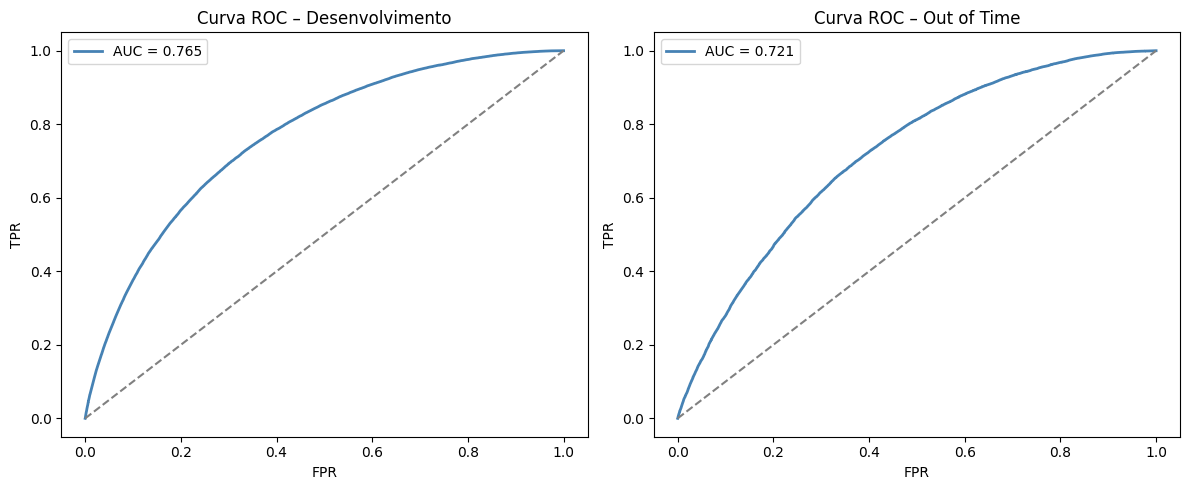

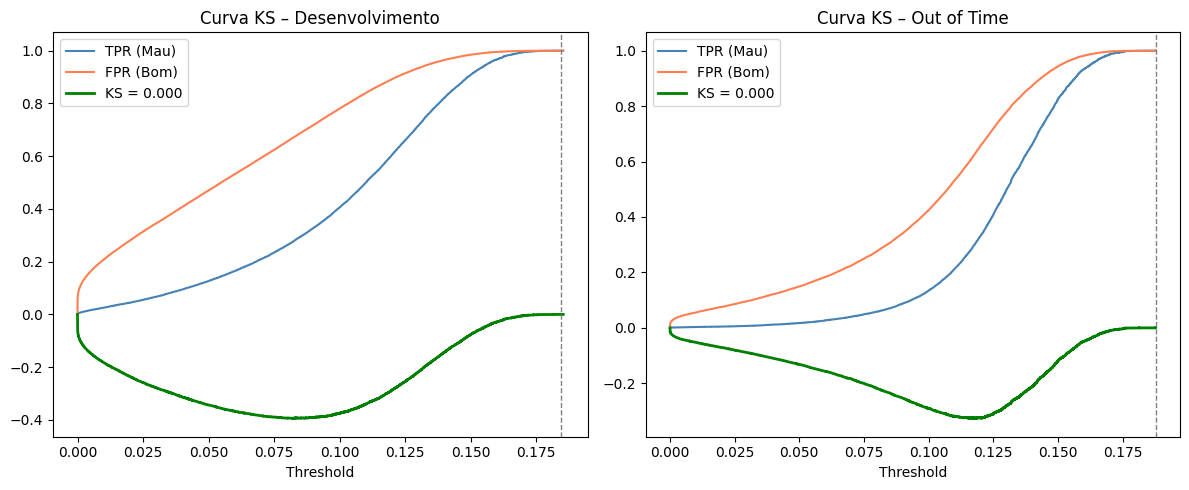

In [8]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
from scipy.stats import ks_2samp

def avaliar_modelo(nome, y_true, y_pred, y_proba):
    auc  = roc_auc_score(y_true, y_proba)
    gini = 2 * auc - 1
    ks   = ks_2samp(y_proba[y_true.values == 1],
                    y_proba[y_true.values == 0]).statistic
    acc  = accuracy_score(y_true, y_pred)
    print(f'--- {nome} ---')
    print(f'  Acurácia : {acc:.4f}')
    print(f'  AUC-ROC  : {auc:.4f}')
    print(f'  Gini     : {gini:.4f}')
    print(f'  KS       : {ks:.4f}')
    print()
    return auc

def ks_curve_vetorizado(y_true, y_proba):
    """Calcula a curva KS de forma vetorizada (sem loops)."""
    y_true = np.array(y_true)
    ordem  = np.argsort(y_proba)
    y_sort = y_true[ordem]
    n_pos  = y_sort.sum()
    n_neg  = len(y_sort) - n_pos
    tpr = np.cumsum(y_sort)      / n_pos   # fração de maus capturados
    fpr = np.cumsum(1 - y_sort)  / n_neg   # fração de bons capturados
    thresholds = np.sort(y_proba)
    return thresholds, tpr, fpr

# ── Predições ─────────────────────────────────────────────────────────────────
y_dev_pred  = lr.predict(X_dev_sc)
y_dev_proba = lr.predict_proba(X_dev_sc)[:, 1]
y_oot_pred  = lr.predict(X_oot_sc)
y_oot_proba = lr.predict_proba(X_oot_sc)[:, 1]

print('=== Avaliação do Modelo — Regressão Logística ===\n')
auc_dev = avaliar_modelo('Desenvolvimento', y_dev, y_dev_pred, y_dev_proba)
auc_oot = avaliar_modelo('Out of Time (OOT)', y_oot, y_oot_pred, y_oot_proba)

# ── Curvas ROC ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, nome, y_true, y_proba, auc in [
    (axes[0], 'Desenvolvimento', y_dev, y_dev_proba, auc_dev),
    (axes[1], 'Out of Time',     y_oot, y_oot_proba, auc_oot),
]:
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    ax.plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc:.3f}')
    ax.plot([0, 1], [0, 1], '--', color='grey')
    ax.set_title(f'Curva ROC – {nome}')
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.legend()
plt.tight_layout()
plt.show()

# ── Curva KS (vetorizada) ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, nome, y_true, y_proba in [
    (axes[0], 'Desenvolvimento', y_dev, y_dev_proba),
    (axes[1], 'Out of Time',     y_oot, y_oot_proba),
]:
    thresh, tpr_ks, fpr_ks = ks_curve_vetorizado(y_true, y_proba)
    ks_vals = tpr_ks - fpr_ks
    idx_max = np.argmax(ks_vals)

    ax.plot(thresh, tpr_ks, label='TPR (Mau)',  color='steelblue', lw=1.5)
    ax.plot(thresh, fpr_ks, label='FPR (Bom)',  color='coral',     lw=1.5)
    ax.plot(thresh, ks_vals, label=f'KS = {ks_vals[idx_max]:.3f}',
            color='green', lw=2)
    ax.axvline(thresh[idx_max], color='grey', linestyle='--', lw=1)
    ax.set_title(f'Curva KS – {nome}')
    ax.set_xlabel('Threshold'); ax.legend()
plt.tight_layout()
plt.show()


# a - Criar um pipeline utilizando o sklearn pipeline para o preprocessamento 

## Pré processamento

### Substituição de nulos (nans)

Existe nulos na base? é dado numérico ou categórico? qual o valor de substituição? média? valor mais frequente? etc

In [9]:

# ── Verificação de nulos na base de desenvolvimento ───────────────────────────
miss_dev = X_dev.isnull().sum().rename('missing_dev')
miss_oot = X_oot.isnull().sum().rename('missing_oot')

miss_report = pd.concat([miss_dev, miss_oot], axis=1)
miss_report['tipo'] = ['numérico' if c in vars_quant else 'categórico'
                       for c in miss_report.index]
print('Missings por variável:\n')
print(miss_report.to_string())
print(f'\nTotal dev : {miss_dev.sum()} | Total oot : {miss_oot.sum()}')


Missings por variável:

                       missing_dev  missing_oot        tipo
qtd_filhos                       0            0    numérico
idade                            0            0    numérico
tempo_emprego               100875        25082    numérico
qt_pessoas_residencia            0            0    numérico
renda                            0            0    numérico
sexo                             0            0  categórico
posse_de_veiculo                 0            0  categórico
posse_de_imovel                  0            0  categórico
tipo_renda                       0            0  categórico
educacao                         0            0  categórico
estado_civil                     0            0  categórico
tipo_residencia                  0            0  categórico

Total dev : 100875 | Total oot : 25082


In [10]:

from sklearn.impute import SimpleImputer

# Numérico → mediana (robusta a outliers)
imputer_num = SimpleImputer(strategy='median')
# Categórico → moda (valor mais frequente)
imputer_cat = SimpleImputer(strategy='most_frequent')

print('Imputadores definidos:')
print(f'  Numérico  ({vars_quant}) → mediana')
print(f'  Categórico ({vars_quali}) → moda')


Imputadores definidos:
  Numérico  (['qtd_filhos', 'idade', 'tempo_emprego', 'qt_pessoas_residencia', 'renda']) → mediana
  Categórico (['sexo', 'posse_de_veiculo', 'posse_de_imovel', 'tipo_renda', 'educacao', 'estado_civil', 'tipo_residencia']) → moda


### Remoção de outliers

Como identificar outlier? Substituir o outlier por algum valor? Remover a linha?

In [11]:

# ── Identificação de outliers via IQR ─────────────────────────────────────────
print('Análise de outliers (IQR ×1.5) – base de desenvolvimento:\n')
for col in vars_quant:
    q1 = X_dev[col].quantile(0.25)
    q3 = X_dev[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_out = ((X_dev[col] < lower) | (X_dev[col] > upper)).sum()
    print(f'{col:30s}: {n_out:5d} outliers ({n_out/len(X_dev):.2%})'
          f'  |  limites [{lower:.2f}, {upper:.2f}]')

# Estratégia: winsorização (substituição pelos limites p1/p99)
# → mantém todas as linhas sem distorcer o modelo.
print('\nEstratégia adotada: winsorização com p1/p99 (calculados na base dev).')


Análise de outliers (IQR ×1.5) – base de desenvolvimento:

qtd_filhos                    :  8044 outliers (1.34%)  |  limites [-1.50, 2.50]
idade                         :     0 outliers (0.00%)  |  limites [5.50, 81.50]
tempo_emprego                 : 27826 outliers (4.64%)  |  limites [-7.65, 20.88]
qt_pessoas_residencia         :  7722 outliers (1.29%)  |  limites [0.50, 4.50]
renda                         : 62742 outliers (10.46%)  |  limites [-20766.80, 47066.27]

Estratégia adotada: winsorização com p1/p99 (calculados na base dev).


In [12]:

from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np

class OutlierCapper(BaseEstimator, TransformerMixin):
    """Winsorização: substitui valores abaixo de p_lower e acima de p_upper
    pelos respectivos percentis, calculados no conjunto de treino (fit)."""

    def __init__(self, p_lower: float = 0.01, p_upper: float = 0.99):
        self.p_lower = p_lower
        self.p_upper = p_upper

    def fit(self, X, y=None):
        X = np.array(X, dtype=float)
        self.lower_ = np.nanpercentile(X, self.p_lower * 100, axis=0)
        self.upper_ = np.nanpercentile(X, self.p_upper * 100, axis=0)
        return self

    def transform(self, X, y=None):
        X = np.array(X, dtype=float).copy()
        return np.clip(X, self.lower_, self.upper_)

print('OutlierCapper definido.')


OutlierCapper definido.


In [13]:

# ── Teste rápido do OutlierCapper ─────────────────────────────────────────────
import pandas as pd
_test = X_dev[vars_quant].copy().fillna(0)
capper_test = OutlierCapper(p_lower=0.01, p_upper=0.99)
capper_test.fit(_test)
_out = capper_test.transform(_test)
print(f'Shape entrada : {_test.shape}  |  Shape saída: {_out.shape}')
print('\nLimites aprendidos (p1/p99):')
for col, lo, hi in zip(vars_quant, capper_test.lower_, capper_test.upper_):
    print(f'  {col:30s}: [{lo:.4f}, {hi:.4f}]')


Shape entrada : (600000, 5)  |  Shape saída: (600000, 5)

Limites aprendidos (p1/p99):
  qtd_filhos                    : [0.0000, 3.0000]
  idade                         : [25.0000, 66.0000]
  tempo_emprego                 : [0.0000, 30.5671]
  qt_pessoas_residencia         : [1.0000, 5.0000]
  renda                         : [858.2000, 326248.0900]


### Seleção de variáveis

Qual tipo de técnica? Boruta? Feature importance? 

In [14]:

# ── Seleção de variáveis – Feature Importance (Random Forest) ─────────────────
# Técnica: feature importance de um RandomForestClassifier, que mede
# quanto cada variável reduz a impureza média nos nós das árvores.
# É não-paramétrica, lida com categorias após dummificação e é estável.

from sklearn.ensemble      import RandomForestClassifier
from sklearn.impute        import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose       import ColumnTransformer
import pandas as pd

# Subamostrar para 30k linhas — a importância relativa das variáveis
# não muda com volumes maiores, mas o tempo cai drasticamente.
SAMPLE = 30_000
rng = 42
X_sample = X_dev.sample(n=min(SAMPLE, len(X_dev)), random_state=rng)
y_sample = y_dev.loc[X_sample.index]

# Pré-processar (sem escalar – RF não precisa)
_pre = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'),
             vars_quant),
    ('cat', OneHotEncoder(handle_unknown='ignore',
                          sparse_output=False,
                          drop='first'),
             vars_quali),
])
_X = _pre.fit_transform(X_sample)
_col_names = (vars_quant +
              list(_pre.named_transformers_['cat']
                   .get_feature_names_out(vars_quali)))

# 100 árvores rasas são suficientes para ranquear importâncias
rf_sel = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,          # limita profundidade → muito mais rápido
    max_features='sqrt',
    n_jobs=-1,
    random_state=rng,
)
rf_sel.fit(_X, y_sample)

importances = pd.Series(rf_sel.feature_importances_, index=_col_names)
print(f'Treinado em {len(X_sample):,} linhas\n')
print('Feature Importances – Top 15:\n')
print(importances.sort_values(ascending=False).head(15).to_string())


Treinado em 30,000 linhas

Feature Importances – Top 15:

renda                          0.651286
tempo_emprego                  0.129285
idade                          0.061064
qt_pessoas_residencia          0.021030
qtd_filhos                     0.013522
posse_de_imovel_S              0.013162
posse_de_veiculo_S             0.011164
sexo_M                         0.010749
tipo_renda_Empresário          0.008934
tipo_residencia_Com os pais    0.008047
educacao_Superior completo     0.007960
educacao_Médio                 0.007905
estado_civil_Solteiro          0.007633
estado_civil_União             0.007463
tipo_residencia_Casa           0.006576


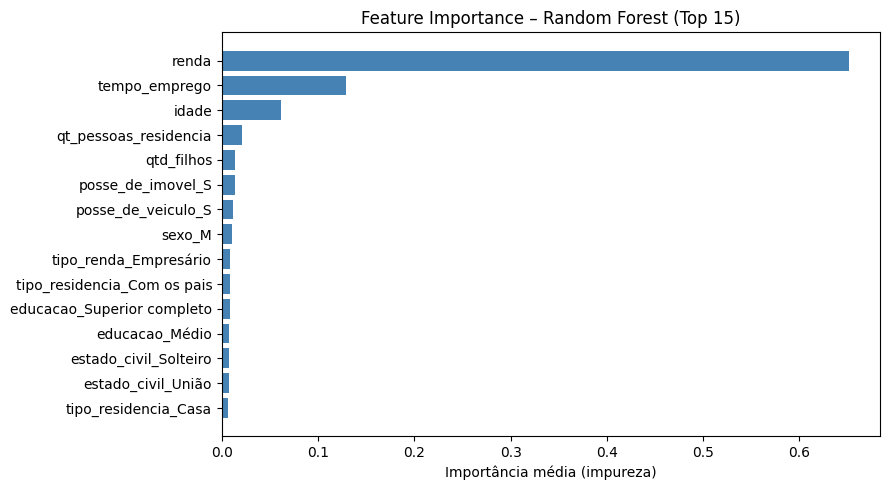

In [15]:

import matplotlib.pyplot as plt

# ── Gráfico de importâncias ───────────────────────────────────────────────────
top15 = importances.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top15.index[::-1], top15.values[::-1], color='steelblue')
ax.set_xlabel('Importância média (impureza)')
ax.set_title('Feature Importance – Random Forest (Top 15)')
plt.tight_layout()
plt.show()


In [16]:

# Variáveis quantitativas com importância > 1 %
selected_quant = [c for c in vars_quant if importances.get(c, 0) > 0.01]
print('Variáveis quantitativas selecionadas:', selected_quant)
# As qualitativas serão mantidas integralmente no pipeline (via dummies)


Variáveis quantitativas selecionadas: ['qtd_filhos', 'idade', 'tempo_emprego', 'qt_pessoas_residencia', 'renda']


### Redução de dimensionalidade (PCA)

Aplicar PCA para reduzir a dimensionalidade para 5

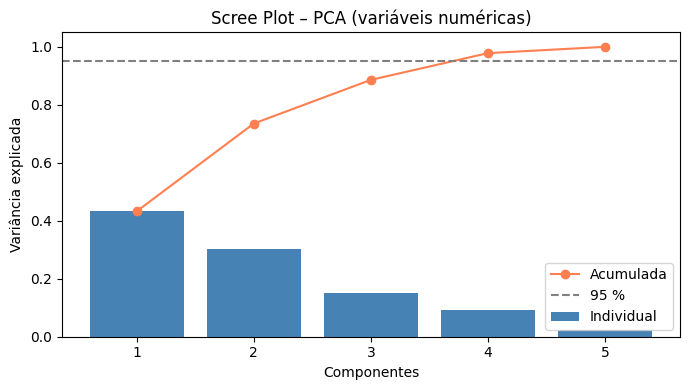


Variância acumulada por componente:
  PC1: 43.26%
  PC2: 73.54%
  PC3: 88.60%
  PC4: 97.82%
  PC5: 100.00%


In [17]:

from sklearn.decomposition  import PCA
from sklearn.preprocessing  import StandardScaler
from sklearn.impute         import SimpleImputer
import matplotlib.pyplot as plt
import numpy as np

# ── Análise de variância explicada antes de fixar n_components ────────────────
_X_num = SimpleImputer(strategy='median').fit_transform(X_dev[vars_quant])
_X_sc  = StandardScaler().fit_transform(_X_num)

pca_analysis = PCA().fit(_X_sc)
cum_var = np.cumsum(pca_analysis.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(1, len(cum_var)+1), pca_analysis.explained_variance_ratio_,
       color='steelblue', label='Individual')
ax.plot(range(1, len(cum_var)+1), cum_var, 'o-', color='coral', label='Acumulada')
ax.axhline(0.95, linestyle='--', color='grey', label='95 %')
ax.set_xlabel('Componentes'); ax.set_ylabel('Variância explicada')
ax.set_title('Scree Plot – PCA (variáveis numéricas)')
ax.legend(); plt.tight_layout(); plt.show()

print('\nVariância acumulada por componente:')
for i, v in enumerate(cum_var, 1):
    print(f'  PC{i}: {v:.2%}')


In [18]:

from sklearn.decomposition import PCA

# n_components=5 conforme solicitado no enunciado.
# Como temos exatamente 5 variáveis numéricas, isso é equivalente a
# reter toda a variância dessas variáveis em base ortogonal.
pca = PCA(n_components=5, random_state=42)
print(f'PCA configurado: n_components={pca.n_components}')


PCA configurado: n_components=5


### Criação de dummies

Aplicar o get_dummies() ou onehotencoder() para transformar colunas catégoricas do dataframe em colunas de 0 e 1. 
- sexo
- posse_de_veiculo
- posse_de_imovel
- tipo_renda
- educacao
- estado_civil
- tipo_residencia

In [19]:

# ── Verificar categorias de cada variável qualitativa ─────────────────────────
print('Categorias por variável qualitativa (base dev):\n')
for col in vars_quali:
    cats = sorted(X_dev[col].dropna().unique())
    print(f'{col} ({len(cats)} cats): {cats}')


Categorias por variável qualitativa (base dev):

sexo (2 cats): ['F', 'M']
posse_de_veiculo (2 cats): ['N', 'S']
posse_de_imovel (2 cats): ['N', 'S']
tipo_renda (5 cats): ['Assalariado', 'Bolsista', 'Empresário', 'Pensionista', 'Servidor público']
educacao (5 cats): ['Fundamental', 'Médio', 'Pós graduação', 'Superior completo', 'Superior incompleto']
estado_civil (5 cats): ['Casado', 'Separado', 'Solteiro', 'União', 'Viúvo']
tipo_residencia (6 cats): ['Aluguel', 'Casa', 'Com os pais', 'Comunitário', 'Estúdio', 'Governamental']


In [20]:

from sklearn.preprocessing import OneHotEncoder

# OneHotEncoder:
#   drop='first'          → evita multicolinearidade (dummy trap)
#   handle_unknown='ignore' → novas categorias no OOT viram coluna 0
#   sparse_output=False   → retorna array denso (compatível com ColumnTransformer)
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first')
print('OneHotEncoder configurado.')
print('  drop="first"  | handle_unknown="ignore"  | sparse_output=False')


OneHotEncoder configurado.
  drop="first"  | handle_unknown="ignore"  | sparse_output=False


### Pipeline 

Crie um pipeline contendo essas funções.

preprocessamento()
- substituicao de nulos
- remoção outliers
- PCA
- Criação de dummy de pelo menos 1 variável (posse_de_veiculo)

In [21]:

from sklearn.pipeline        import Pipeline
from sklearn.compose         import ColumnTransformer
from sklearn.impute          import SimpleImputer
from sklearn.preprocessing   import StandardScaler, OneHotEncoder
from sklearn.decomposition   import PCA
from sklearn.linear_model    import LogisticRegression

# ── Sub-pipeline numérico ─────────────────────────────────────────────────────
pipe_num = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('outlier', OutlierCapper(p_lower=0.01, p_upper=0.99)),
    ('scaler',  StandardScaler()),
])

# ── Sub-pipeline categórico ───────────────────────────────────────────────────
pipe_cat = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore',
                              sparse_output=False, drop='first')),
])

# ── ColumnTransformer ─────────────────────────────────────────────────────────
preprocessor = ColumnTransformer([
    ('num', pipe_num, vars_quant),
    ('cat', pipe_cat, vars_quali),
])

# ── Pipeline completo: preprocessamento → PCA → Regressão Logística ──────────
# saga: solver estocástico, muito mais rápido que lbfgs para n grande (600k)
# n_jobs=-1: usa todos os cores disponíveis
pipeline = Pipeline([
    ('preprocessamento', preprocessor),
    ('pca',   PCA(n_components=5, random_state=42)),
    ('modelo', LogisticRegression(max_iter=500, random_state=42,
                                  solver='saga', n_jobs=-1)),
])

print(pipeline)


Pipeline(steps=[('preprocessamento',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('outlier',
                                                                   OutlierCapper()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['qtd_filhos', 'idade',
                                                   'tempo_emprego',
                                                   'qt_pessoas_residencia',
                                                   'renda']),
                                                 ('cat',
                                                  Pipeline(st

In [22]:

from sklearn.metrics import accuracy_score, roc_auc_score
from scipy.stats     import ks_2samp

# ── Treinar o pipeline ────────────────────────────────────────────────────────
pipeline.fit(X_dev, y_dev)
print('Pipeline treinado com sucesso!\n')

# ── Avaliação ─────────────────────────────────────────────────────────────────
print('=== Avaliação do Pipeline (sklearn) ===\n')
for nome, X, y in [('Desenvolvimento', X_dev, y_dev), ('Out of Time', X_oot, y_oot)]:
    y_pred  = pipeline.predict(X)
    y_proba = pipeline.predict_proba(X)[:, 1]
    auc  = roc_auc_score(y, y_proba)
    gini = 2 * auc - 1
    ks   = ks_2samp(y_proba[y.values == 1], y_proba[y.values == 0]).statistic
    print(f'--- {nome} ---')
    print(f'  Acurácia : {accuracy_score(y, y_pred):.4f}')
    print(f'  AUC-ROC  : {auc:.4f}')
    print(f'  Gini     : {gini:.4f}')
    print(f'  KS       : {ks:.4f}')
    print()


Pipeline treinado com sucesso!

=== Avaliação do Pipeline (sklearn) ===

--- Desenvolvimento ---
  Acurácia : 0.9389
  AUC-ROC  : 0.7443
  Gini     : 0.4885
  KS       : 0.3698

--- Out of Time ---
  Acurácia : 0.8533
  AUC-ROC  : 0.6797
  Gini     : 0.3595
  KS       : 0.2690



# b - Pycaret na base de dados 

Utilize o pycaret para pre processar os dados e rodar o modelo **lightgbm**. Faça todos os passos a passos da aula e gere os gráficos finais. E o pipeline de toda a transformação.



In [23]:
# ── Verificar se o PyCaret já está instalado ─────────────────────────────────
import sys, importlib

if importlib.util.find_spec('pycaret') is not None:
    import pycaret
    print(f'✅ PyCaret já instalado — versão {pycaret.__version__}')
else:
    print('⚠️  PyCaret NÃO encontrado neste kernel.')
    print()
    print('═' * 60)
    print('INSTALE VIA ANACONDA PROMPT (fora do Jupyter):')
    print('═' * 60)
    print()
    print('  1. Abra o "Anaconda Prompt"')
    print('  2. Execute os comandos abaixo:')
    print()
    print('     conda activate streamlit311')
    print('     pip install pycaret lightgbm --prefer-binary')
    print()
    print('  3. Aguarde a instalação terminar')
    print('  4. Volte aqui e faça: Kernel → Restart Kernel')
    print('  5. Execute todas as células do início')
    print()
    print('Motivo: o Windows bloqueia arquivos .pyd já carregados pelo kernel.')
    print(f'Python atual: {sys.executable}')


✅ PyCaret já instalado — versão 3.3.2


In [24]:

from pycaret.classification import setup as pc_setup

# ── Base de desenvolvimento para o PyCaret ────────────────────────────────────
df_pycaret = df_dev[features + [target]].copy()
df_pycaret[target] = df_pycaret[target].astype(int)

# Subamostrar 50k linhas estratificadas → setup e CV ~12x mais rápidos.
# A distribuição do target é preservada (stratify por mau).
SAMPLE_PY = 50_000
df_pycaret = (df_pycaret
              .groupby(target, group_keys=False)
              .apply(lambda g: g.sample(frac=SAMPLE_PY / len(df_pycaret),
                                        random_state=42))
              .reset_index(drop=True))

print(f'Shape: {df_pycaret.shape}')
print(f'Distribuição do target:\n{df_pycaret[target].value_counts()}')
print(f'Taxa mau: {df_pycaret[target].mean():.2%}')


Shape: (50000, 13)
Distribuição do target:
mau
0    46946
1     3054
Name: count, dtype: int64
Taxa mau: 6.11%


In [25]:
import pandas as pd

df = pd.read_feather('credit_scoring.ftr')
df.head()

,data_ref,index,sexo,posse_de_veiculo,posse_de_imovel,qtd_filhos,tipo_renda,educacao,estado_civil,tipo_residencia,idade,tempo_emprego,qt_pessoas_residencia,renda,mau
0,2015-01-01,5733,F,N,N,0,Empresário,Médio,Solteiro,Casa,43,6.873973,1.0,2515.39,False
1,2015-01-01,727,F,S,S,0,Assalariado,Médio,Casado,Casa,35,4.526027,2.0,3180.19,False
2,2015-01-01,6374,F,N,N,2,Assalariado,Médio,Casado,Casa,31,0.243836,4.0,1582.29,False
3,2015-01-01,9566,F,N,N,0,Assalariado,Médio,Casado,Casa,54,12.772603,2.0,13721.17,False
4,2015-01-01,9502,F,S,N,0,Assalariado,Superior incompleto,Solteiro,Casa,31,8.432877,1.0,2891.08,False


In [26]:

from pycaret.classification import *

# ── Setup do PyCaret ──────────────────────────────────────────────────────────
clf = setup(
    data            = df_pycaret,
    target          = 'mau',
    session_id      = 42,
    normalize       = True,
    normalize_method= 'zscore',
    transformation  = True,
    ignore_features = [],
    remove_multicollinearity    = True,
    multicollinearity_threshold = 0.9,
    fix_imbalance   = False,
    verbose         = True,
)


,Description,Value
0,Session id,42
1,Target,mau
2,Target type,Binary
3,Original data shape,"(50000, 13)"
4,Transformed data shape,"(50000, 30)"
5,Transformed train set shape,"(35000, 30)"
6,Transformed test set shape,"(15000, 30)"
7,Numeric features,5
8,Categorical features,7
9,Rows with missing values,16.6%


In [27]:

# ── Criar modelo LightGBM ─────────────────────────────────────────────────────
# fold=3 → 3-fold CV (padrão é 10-fold, portanto 3x mais rápido)
lgbm = create_model('lightgbm', fold=3)


In [28]:

# ── Tunar o modelo ────────────────────────────────────────────────────────────
# fold=3  → 3-fold CV em vez de 10-fold (3× mais rápido)
# n_iter=10 → 10 combinações de hiperparâmetros (suficiente para LightGBM)
lgbm_tuned = tune_model(lgbm, optimize='AUC', n_iter=10, fold=3)


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9389,0.7707,0.0000,0.0000,0.0000,0.0000,0.0000
1,0.9389,0.7699,0.0000,0.0000,0.0000,0.0000,0.0000
2,0.9390,0.7568,0.0000,0.0000,0.0000,0.0000,0.0000
Mean,0.9389,0.7658,0.0000,0.0000,0.0000,0.0000,0.0000
Std,0.0000,0.0064,0.0000,0.0000,0.0000,0.0000,0.0000


Fitting 3 folds for each of 10 candidates, totalling 30 fits


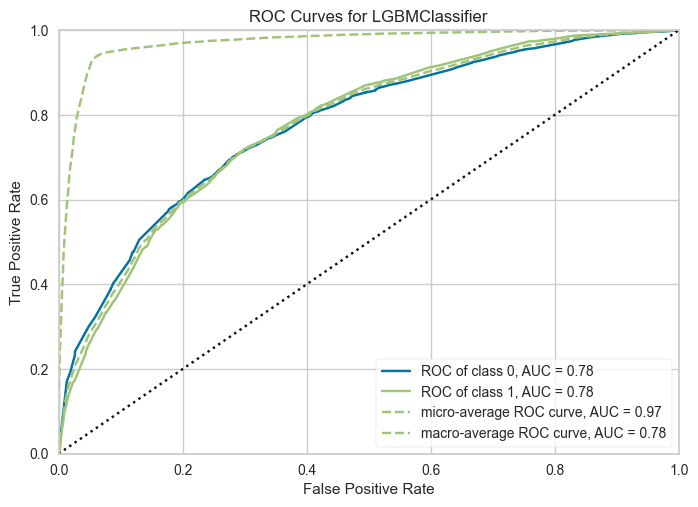

In [29]:

# ── Curva ROC ─────────────────────────────────────────────────────────────────
plot_model(lgbm_tuned, plot='auc')


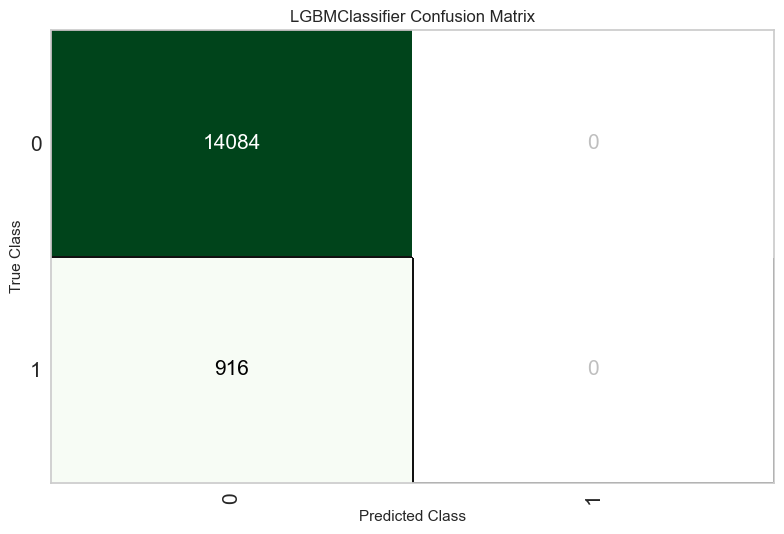

In [30]:

# ── Matriz de confusão ────────────────────────────────────────────────────────
plot_model(lgbm_tuned, plot='confusion_matrix')


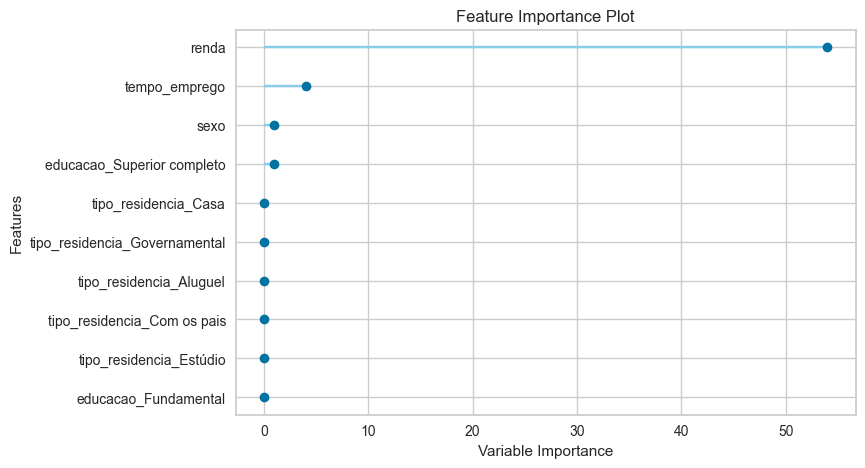

In [31]:

# ── Feature importance do LightGBM ───────────────────────────────────────────
plot_model(lgbm_tuned, plot='feature')


In [32]:

# ── Finalizar o modelo (treinar em toda a base de dev) ────────────────────────
lgbm_final = finalize_model(lgbm_tuned)
print('Modelo finalizado.')


Modelo finalizado.


In [33]:

import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score
from scipy.stats     import ks_2samp

# ── Predições no OOT ─────────────────────────────────────────────────────────
df_oot_py = df_oot[features].copy()
df_oot_py['mau'] = df_oot[target].astype(int)

pred_oot = predict_model(lgbm_final, data=df_oot_py)

# Colunas de predição do PyCaret 3.x
proba_col = 'prediction_score' if 'prediction_score' in pred_oot.columns else 'Score'
label_col = 'prediction_label' if 'prediction_label' in pred_oot.columns else 'Label'

y_oot_true  = pred_oot['mau']
y_oot_label = pred_oot[label_col]
y_oot_score = pred_oot[proba_col]

auc  = roc_auc_score(y_oot_true, y_oot_score)
gini = 2 * auc - 1
ks   = ks_2samp(y_oot_score[y_oot_true == 1], y_oot_score[y_oot_true == 0]).statistic

print('=== Avaliação OOT – LightGBM (PyCaret) ===\n')
print(f'  Acurácia : {accuracy_score(y_oot_true, y_oot_label):.4f}')
print(f'  AUC-ROC  : {auc:.4f}')
print(f'  Gini     : {gini:.4f}')
print(f'  KS       : {ks:.4f}')


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Light Gradient Boosting Machine,0.8533,0.7371,0.0000,0.0000,0.0000,0.0000,0.0000


[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] bagging_fraction is set=0.6, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6
[LightGBM] [Warning] bagging_freq is set=0, subsample_freq=0 will be ignored. Current value: bagging_freq=0
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] bagging_fraction is set=0.6, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6
[LightGBM] [Warning] bagging_freq is set=0, subsample_freq=0 will be ignored. Current value: bagging_freq=0
=== Avaliação OOT – LightGBM (PyCaret) ===

  Acurácia : 0.8533
  AUC-ROC  : 0.2629
  Gini     : -0.4742
  KS       : 0.3458


In [34]:

# ── Pipeline completo gerado pelo PyCaret ─────────────────────────────────────
pipe_pycaret = get_config('pipeline')
print(pipe_pycaret)


Pipeline(memory=FastMemory(location=C:\Users\User\AppData\Local\Temp\joblib),
         steps=[('numerical_imputer',
                 TransformerWrapper(exclude=None,
                                    include=['qtd_filhos', 'idade',
                                             'tempo_emprego',
                                             'qt_pessoas_residencia', 'renda'],
                                    transformer=SimpleImputer(add_indicator=False,
                                                              copy=True,
                                                              fill_value=None,
                                                              keep_empty_features=False,
                                                              missing_values=nan,
                                                              strategy='mean'))...
                 TransformerWrapper(exclude=[], include=None,
                                    transformer=RemoveMulticollinearity(t

In [35]:

# ── Salvar o modelo finalizado ────────────────────────────────────────────────
save_model(lgbm_final, 'lgbm_credit_scoring')
print('Modelo salvo em lgbm_credit_scoring.pkl')


Transformation Pipeline and Model Successfully Saved
Modelo salvo em lgbm_credit_scoring.pkl


In [36]:

# ── Carregar e reutilizar o modelo salvo ─────────────────────────────────────
lgbm_loaded = load_model('lgbm_credit_scoring')
pred_check  = predict_model(lgbm_loaded, data=df_oot_py.head())
print(pred_check[['mau', 'prediction_label', 'prediction_score']])


Transformation Pipeline and Model Successfully Loaded


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Light Gradient Boosting Machine,0.8000,0.6250,0.0000,0.0000,0.0000,0.0000,0.0000


[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] bagging_fraction is set=0.6, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6
[LightGBM] [Warning] bagging_freq is set=0, subsample_freq=0 will be ignored. Current value: bagging_freq=0
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] bagging_fraction is set=0.6, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6
[LightGBM] [Warning] bagging_freq is set=0, subsample_freq=0 will be ignored. Current value: bagging_freq=0
        mau  prediction_label  prediction_score
600000    1                 0            0.8962
600001    0                 0            0.9440
600002    0                 0            0.9624
600003    0                 0            0.8929
600004    0                 0            0.8962
